In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/cleaned_orders.csv")
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(110194, 34)


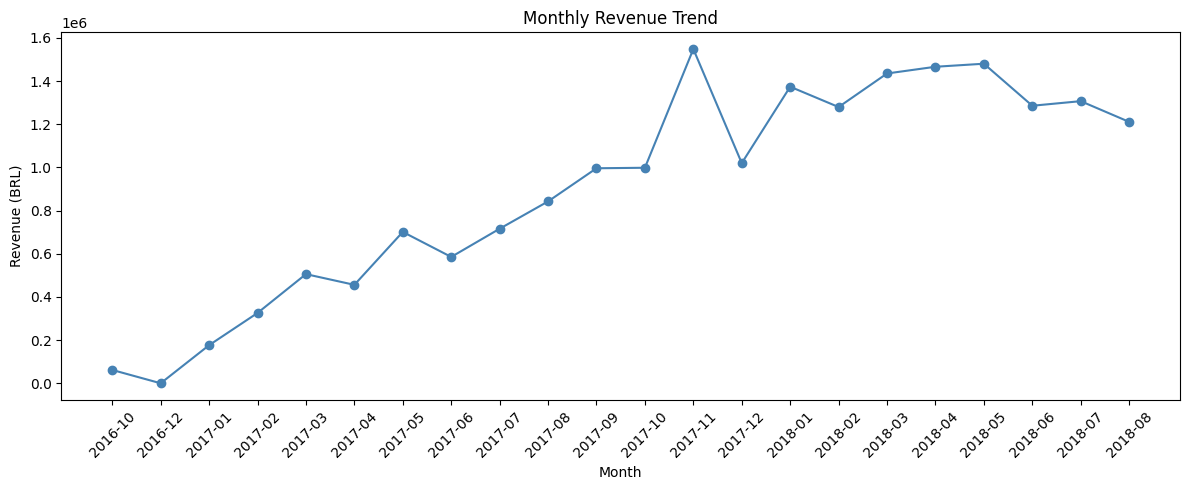

In [5]:
monthly_revenue = df.groupby('order_month')['payment_value'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['order_month'].astype(str), monthly_revenue['payment_value'], marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

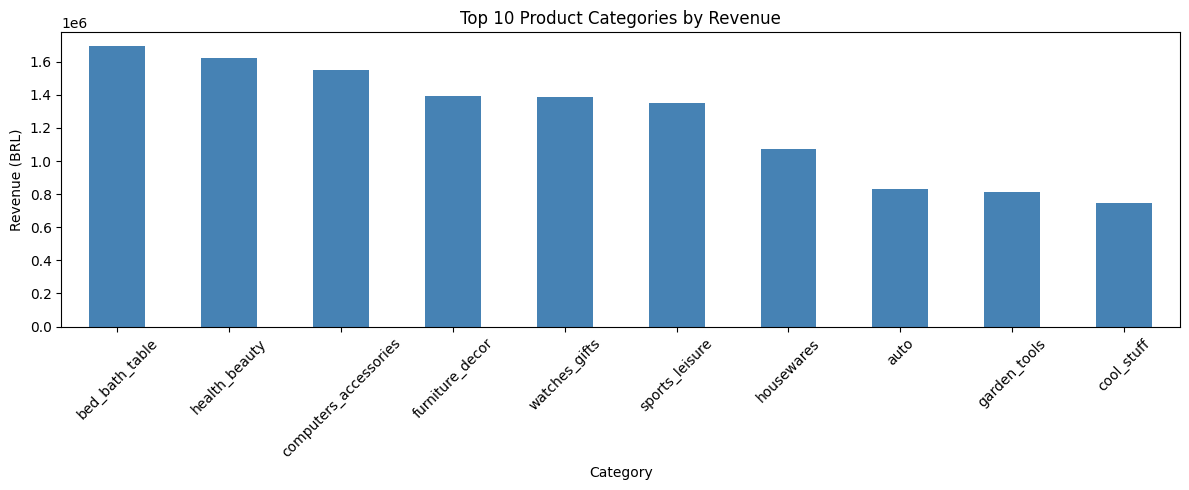

In [6]:
top_categories = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_categories.plot(kind='bar', color='steelblue')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

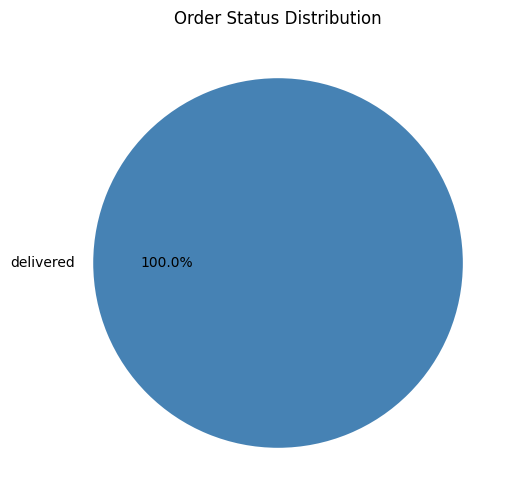

In [7]:
status_counts = df['order_status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['steelblue','orange','green'])
plt.title('Order Status Distribution')
plt.show()

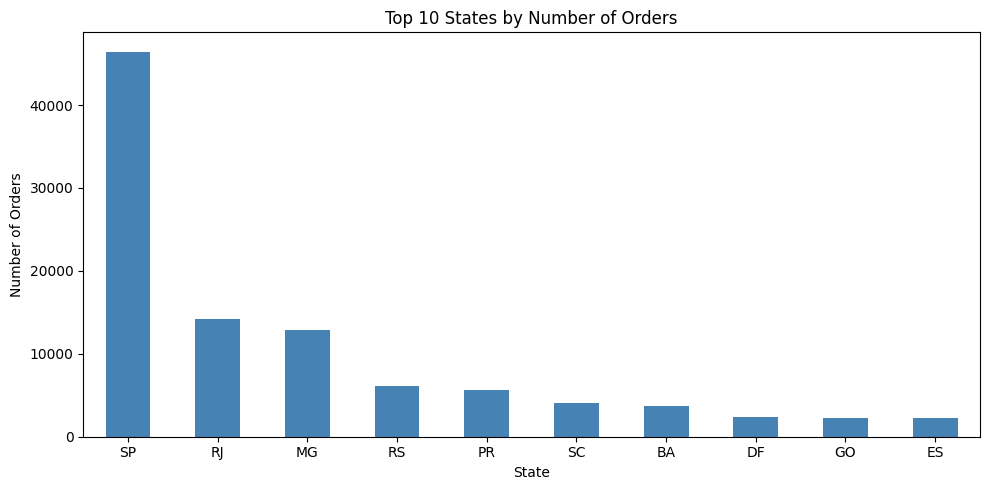

In [8]:
top_states = df.groupby('customer_state')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

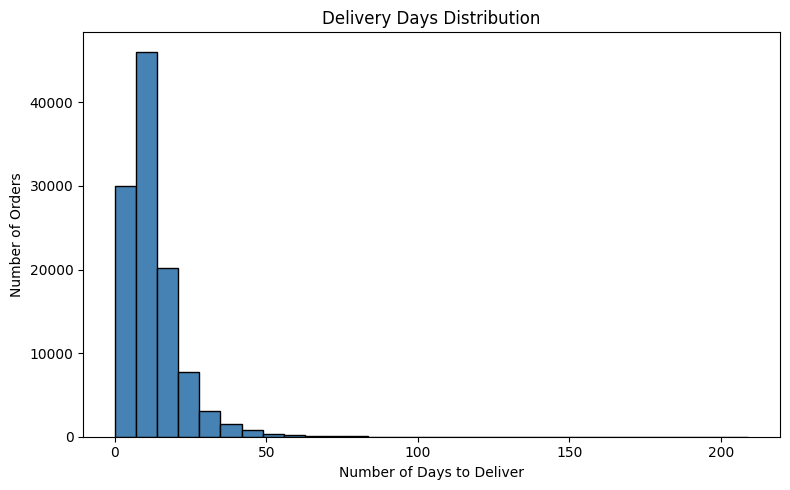

In [14]:
plt.figure(figsize=(8,5))
df['delivery_days'].dropna().plot(kind='hist', bins=30, color='steelblue', edgecolor='black')
plt.title('Delivery Days Distribution')
plt.xlabel('Number of Days to Deliver')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

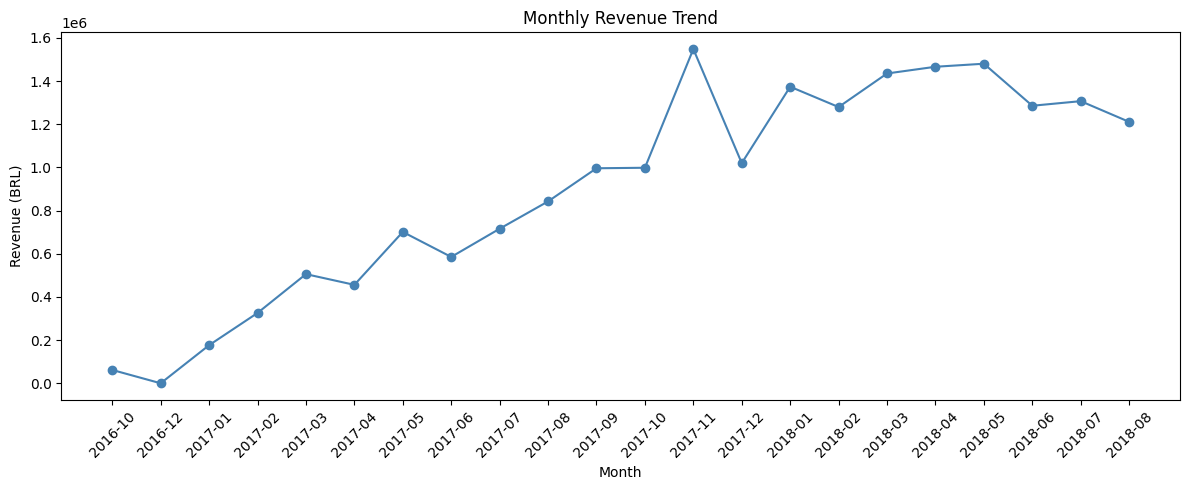

Charts saved to Google Drive! ✅


In [15]:
import os
os.makedirs("/content/drive/MyDrive/charts", exist_ok=True)

# Monthly Revenue
monthly_revenue = df.groupby('order_month')['payment_value'].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['order_month'].astype(str), monthly_revenue['payment_value'], marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/charts/monthly_revenue.png")
plt.show()

print("Charts saved to Google Drive! ✅")